## **Conjunto de datos de clasificación de enfermedades cardíacas: Heart Attack**
Las enfermedades cardiovasculares (ECV) son la principal causa de muerte a nivel mundial. Las ECV incluyen enfermedades coronarias, enfermedades cerebrovasculares, cardiopatías reumáticas y otros problemas cardíacos y vasculares sanguíneos. Según la Organización Mundial de la Salud, mueren 17,9 millones de personas cada año. Los infartos y los ictus representan más de cuatro de cada cinco muertes por ECV, siendo un tercio de estas muertes antes de los 70 años. Se ha creado una base de datos completa sobre los factores que contribuyen a un infarto.

El objetivo principal aquí es recopilar características del infarto o factores que lo contribuyen.
El tamaño del conjunto de datos es de 1319 muestras, que tienen nueve campos, de los cuales ocho son para los campos de entrada y uno para el campo de salida. La edad, el sexo (0 para mujer, 1 para hombre), la frecuencia cardíaca (impulso), la presión arterial sistólica (presión alta), la presión diastólica (presión baja), el azúcar en sangre (glucosa), CK-MB (kcm) y la troponina test (troponina) representan los campos de entrada, mientras que el campo de salida se refiere a la presencia de infarto (clase), que se divide en dos categorías (negativa y positiva); negativo se refiere a la ausencia de un infarto, mientras que positivo se refiere a la presencia de un infarto.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
path = "C:/Users/Jose Manuel/Documents/VisualStudioCode_Workspace/Repo_CEDAPY/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/NOTEBOOKS/EJERCICIOS/heart_attack/Heart Attack.csv"

df_heart_attack = pd.read_csv(path)
df_heart_attack.head()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [3]:
df_heart_attack.shape

(1319, 9)

In [4]:
df_heart_attack.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


- Se observa que no hay valores nulos en cada campo

In [5]:
map_target_class = {'negative': 0, 'positive': 1}
df_heart_attack['class_number'] = df_heart_attack['class'].map(map_target_class)

- Mapeamos la columna de infarto, creando una nueva columna con los datos 0 donde es negativo y 1 donde es positivo

In [6]:
df_heart_attack.head()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class,class_number
0,64,1,66,160,83,160.0,1.80,0.012,negative,0
1,21,1,94,98,46,296.0,6.75,1.060,positive,1
2,55,1,64,160,77,270.0,1.99,0.003,negative,0
3,64,1,70,120,55,270.0,13.87,0.122,positive,1
4,55,1,64,112,65,300.0,1.08,0.003,negative,0


In [7]:
x = df_heart_attack.drop(['class', 'class_number'], axis=1)
y = df_heart_attack['class_number']
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42, stratify=y) 

- Asignamos los valores de x e y
- stratify=y es importante, ya que en temas médicos, a veces hay pocos casos positivos (infartos) comparados con los negativos. Si no usas stratify, podrías terminar con un conjunto de prueba que no tenga ningún caso de infarto, y no sabrías si tu modelo realmente funciona. La estratificación mantiene el equilibrio de casos positivos/negativos en ambos grupos.

- random_state: Te permite compartir tu código con otros y que obtengan exactamente los mismos resultados que tú.Se usa como una "semilla" para que el desorden sea siempre el mismo. Si vuelves a ejecutar el código, obtendrás exactamente los mismos datos en X_train y X_test, lo cual es muy importante a la hora de reproducir tus experimentos.

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

- Escalamos los datos primero para que el modelo no piense por ejemplo que la presión es "más importante" que el sexo solo porque el número es más grande.

## **Heart Attack con LogisticRegression**

In [9]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
predicts_train = lr.predict(X_train)
print(confusion_matrix(y_train, predicts_train))
print(classification_report(y_train, predicts_train))

[[277 105]
 [ 94 513]]
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       382
           1       0.83      0.85      0.84       607

    accuracy                           0.80       989
   macro avg       0.79      0.79      0.79       989
weighted avg       0.80      0.80      0.80       989



- Ahora realizamos las predicciones con los datos de prueba

In [11]:
preds_test = lr.predict(X_test)
print(confusion_matrix(y_test, preds_test))
print(classification_report(y_test, preds_test))

[[ 89  38]
 [ 39 164]]
              precision    recall  f1-score   support

           0       0.70      0.70      0.70       127
           1       0.81      0.81      0.81       203

    accuracy                           0.77       330
   macro avg       0.75      0.75      0.75       330
weighted avg       0.77      0.77      0.77       330



In [12]:
from sklearn.metrics import accuracy_score
accuary_Regression = accuracy_score(y_test, preds_test)
print(f'Precisión: {accuary_Regression*100:.2f}%')

Precisión: 76.67%


### Mapa de calor

<Axes: >

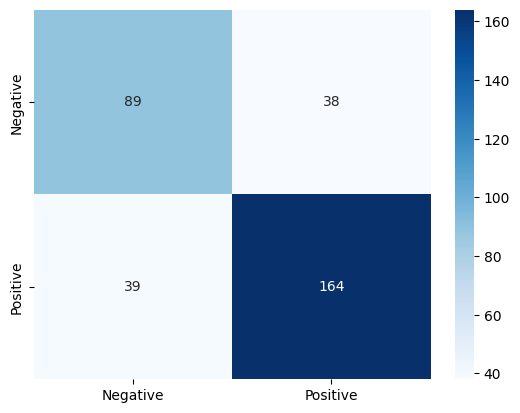

In [13]:
import seaborn as sns

clases = ['Negative', 'Positive']
sns.heatmap(confusion_matrix(y_test, preds_test, labels=lr.classes_),annot=True, fmt=".0f", xticklabels = clases, yticklabels = clases, cmap='Blues')

### Coeficientes mínimos cuadrados W1 y W0 

In [14]:
print("Coeficiente w1:", lr.coef_) 
print("Coeficiente w0:", lr.intercept_)

Coeficiente w1: [[ 0.62527494  0.21887569  0.03262087 -0.12060138  0.09621646 -0.09553859
   5.63914784  3.33548606]]
Coeficiente w0: [2.31358929]


### Coeficientes de determinación (R2)

In [15]:
print("Valor del coeficiente de determinación del conjunto de entrenamiento:", round (lr.score(X_train, y_train), 2))
print("Valor del coeficiente de determinación del conjunto de prueba:", round (lr.score(X_test, y_test), 2))

Valor del coeficiente de determinación del conjunto de entrenamiento: 0.8
Valor del coeficiente de determinación del conjunto de prueba: 0.77


### Gráfico de barras
- Para visualizar las variables que más peso tienen en la predicción

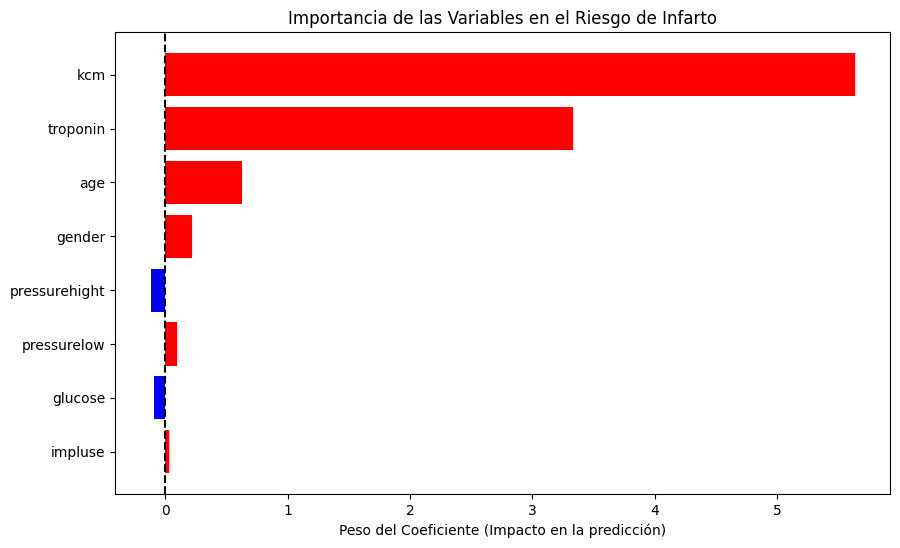

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraer los coeficientes y asociarlos con los nombres de las columnas
importancias = pd.DataFrame({
    'Variable': x.columns,
    'Coeficiente': lr.coef_[0]
})

# 2. Ordenar por el valor absoluto (importancia real, sea positiva o negativa)
importancias['Abs_Coef'] = importancias['Coeficiente'].abs()
importancias = importancias.sort_values(by='Abs_Coef', ascending=True)

# 3. Graficar
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variable'], importancias['Coeficiente'], 
         color=['red' if c > 0 else 'blue' for c in importancias['Coeficiente']])
plt.title('Importancia de las Variables en el Riesgo de Infarto')
plt.xlabel('Peso del Coeficiente (Impacto en la predicción)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

## **Heart_Attack: Clasificación con DecisionTreeClassifier**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [18]:
# Crear y entrenar el modelo
from sklearn.tree import DecisionTreeClassifier, plot_tree

dtc = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
# Evaluar el modelo
y_pred = dtc.predict(X_test)
accuary_DTC = accuracy_score(y_test, y_pred)
print(f"Precisión: {accuary_DTC:.2f}%")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Precisión: 0.98%

Matriz de Confusión:
[[123   5]
 [  2 200]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       128
           1       0.98      0.99      0.98       202

    accuracy                           0.98       330
   macro avg       0.98      0.98      0.98       330
weighted avg       0.98      0.98      0.98       330



### Visualizar el arbol

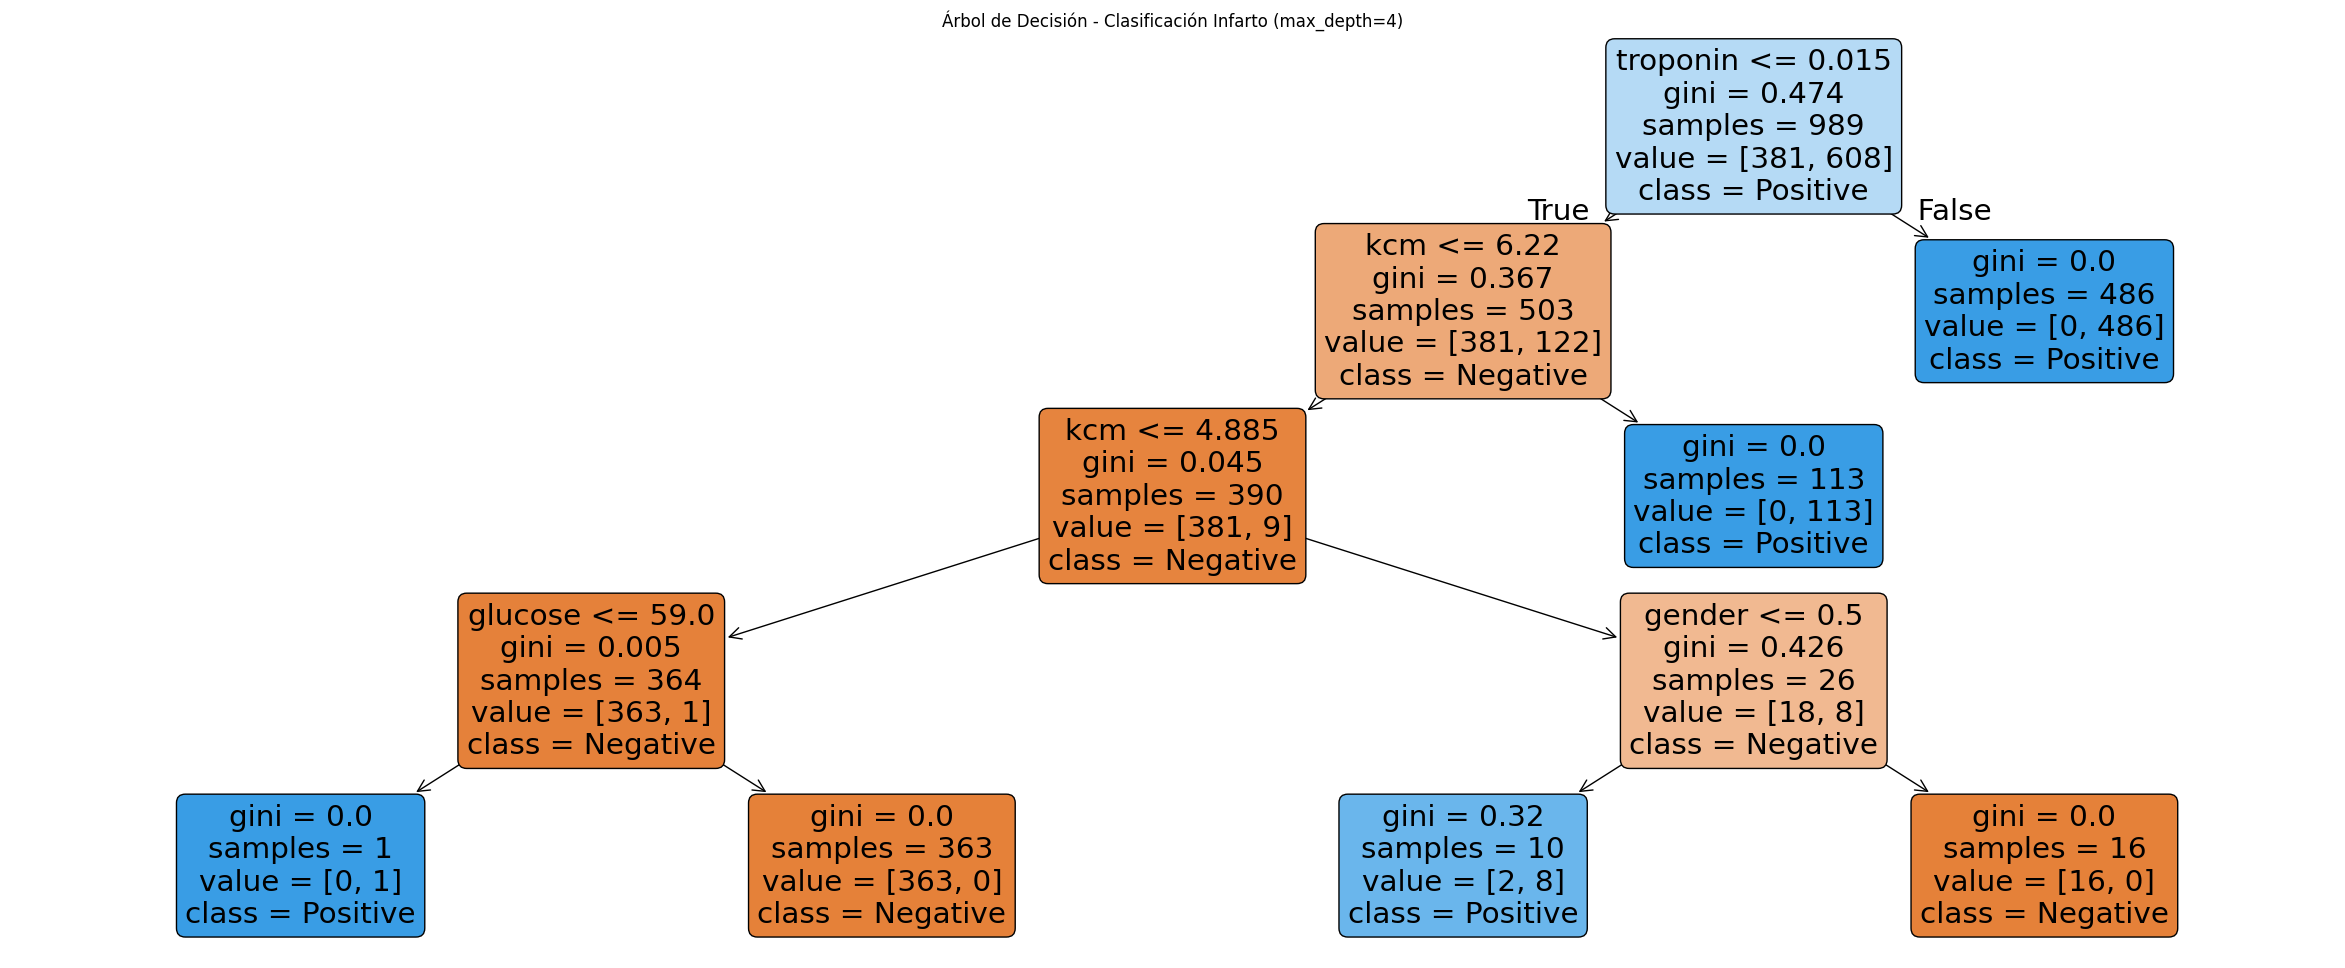

In [20]:
plt.figure(figsize=(30, 12))
plot_tree(dtc,
          filled=True,      # Colorea los nodos
          rounded=True,     # Nodos con bordes redondeados
          class_names=clases, # Nombres de las clases (target)
          feature_names=x.columns) # Nombres de las características (features)
plt.title("Árbol de Decisión - Clasificación Infarto (max_depth=4)")
plt.show()

### Peso de las variables en la predicción (DecisionTreeClassifier)

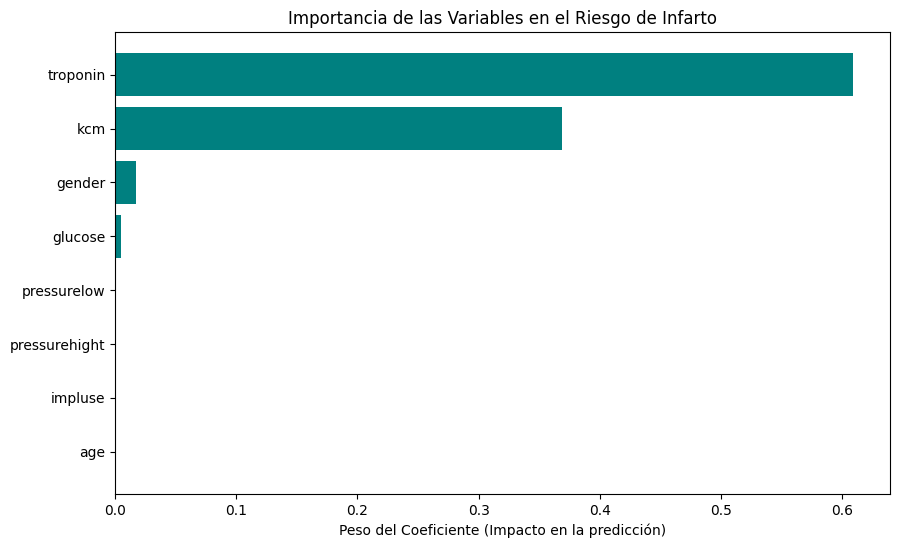

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraer los coeficientes y asociarlos con los nombres de las columnas
importancias = pd.DataFrame({
    'Variable': x.columns,
    'Coeficiente': dtc.feature_importances_
})

# 2. Ordenar de menor a mayor
importancias = importancias.sort_values(by='Coeficiente', ascending=True)

# 3. Graficar
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variable'], importancias['Coeficiente'], color='teal')
plt.title('Importancia de las Variables en el Riesgo de Infarto')
plt.xlabel('Peso del Coeficiente (Impacto en la predicción)')
plt.show()

## **Heart_Attack con RANDOM FOREST**

In [22]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=50, random_state=0)
classifier.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Predicción

In [23]:
y_pred = classifier.predict(X_test)

### Mostrar resultados

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
result = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(result)   
result = classification_report(y_test, y_pred)
print("Classification Report:")
print(result)
accuracy_Random_Forest = accuracy_score(y_test, y_pred)
print(f"Accuracy:{accuracy_Random_Forest.__round__(2)}%")

Confusion Matrix:
[[123   5]
 [  4 198]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       128
           1       0.98      0.98      0.98       202

    accuracy                           0.97       330
   macro avg       0.97      0.97      0.97       330
weighted avg       0.97      0.97      0.97       330

Accuracy:0.97%


### Peso de las variables en la predicción (RandomForestClassifier)

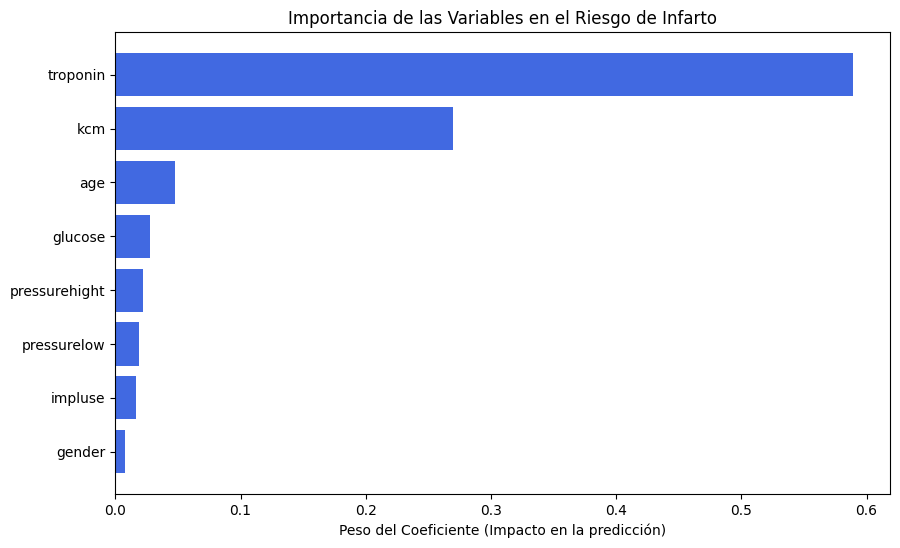

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraer los coeficientes y asociarlos con los nombres de las columnas
importancias = pd.DataFrame({
    'Variable': x.columns,
    'Coeficiente': classifier.feature_importances_
})

# 2. Ordenar de menor a mayor
importancias = importancias.sort_values(by='Coeficiente', ascending=True)

# 3. Graficar
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variable'], importancias['Coeficiente'], color='royalblue')
plt.title('Importancia de las Variables en el Riesgo de Infarto')
plt.xlabel('Peso del Coeficiente (Impacto en la predicción)')
plt.show()

- Obtenemos las columnas con mayor peso y visualizamos las primeras tanto de positivos como negativos para observar el valor de cada una de ellas.

In [26]:
columnas_deseadas = ['age', 'kcm', 'troponin']
df_heart_attack.loc[df_heart_attack['class']=='positive', columnas_deseadas].head()

,age,kcm,troponin
1,21,6.75,1.060
3,64,13.87,0.122
7,63,300.00,2.370
12,64,3.43,5.370
15,61,1.49,0.017


In [27]:
columnas_deseadas = ['age', 'kcm', 'troponin']
df_heart_attack.loc[df_heart_attack['class']=='negative', columnas_deseadas].head()

,age,kcm,troponin
0,64,1.80,0.012
2,55,1.99,0.003
4,55,1.08,0.003
5,58,1.83,0.004
6,32,0.71,0.003


## **Heart Attack con regresor K-NN**

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

- Entrenamiento del modelo

In [29]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=8) #Para decidir la categoría de un dato nuevo, debe mirar a los 8 puntos más cercanos en el espacio de datos y elegir 
                                                 #la categoría más común entre ellos.
classifier.fit(X_train, y_train)

,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


- Predicción

In [30]:
y_pred = classifier.predict(X_test)

- Evaluación del modelo K-NN

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("MATRIZ DE CONFUSIÓN")
print(confusion_matrix(y_test, y_pred))

MATRIZ DE CONFUSIÓN
[[ 70  57]
 [ 74 129]]


In [32]:
accuracy_KNN = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy_KNN:.2f}%')

Accuracy: 0.60%


In [33]:
print("Informe de métricas")
print(classification_report(y_test, y_pred))

Informe de métricas
              precision    recall  f1-score   support

           0       0.49      0.55      0.52       127
           1       0.69      0.64      0.66       203

    accuracy                           0.60       330
   macro avg       0.59      0.59      0.59       330
weighted avg       0.61      0.60      0.61       330



## **Heart Attack con Support Vector Machine (SVM)**

In [34]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Predecir datos de prueba y matriz de confusión

In [35]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test);
cm = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(cm)
accuracy_svm = accuracy_score(y_test, y_pred)
print(f"Accuracy:{accuracy_svm.__round__(2)}%")


Classification Report:
[[104  23]
 [ 37 166]]
Accuracy:0.82%


### Visualizar resultados del conjunto de datos de entrenamiento

c:\Users\Jose Manuel\Documents\VisualStudioCode_Workspace\Repo_CEDAPY\CEDAPY_25_26\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Jose Manuel\Documents\VisualStudioCode_Workspace\Repo_CEDAPY\CEDAPY_25_26\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\Jose Manuel\AppData\Local\Temp\ipykernel_33928\4065245611.py:42: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, idx_x], X_set[y_set == j, idx_y],


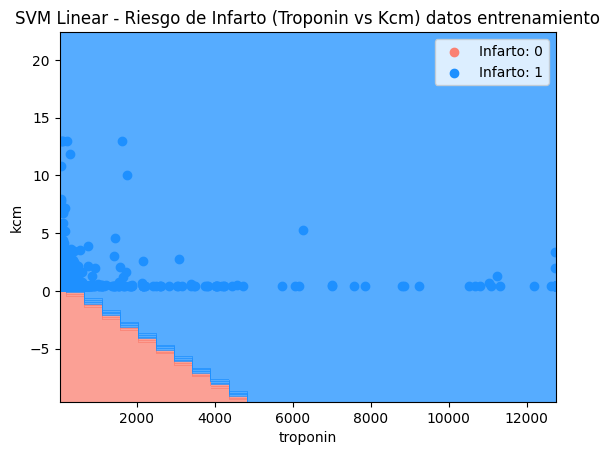

In [36]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparar los datos inversos para los ejes (troponin y kcm)
X_set, y_set = scaler.inverse_transform(X_train), y_train

# Elegimos troponin (índice 6) y kcm (índice 7) para los ejes X e Y
idx_x, idx_y = 6, 7 

# 2. Crear la malla de puntos basada en los rangos reales
X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, idx_x].min() - 5, stop = X_set[:, idx_x].max() + 5, step = 1),
    np.arange(start = X_set[:, idx_y].min() - 10, stop = X_set[:, idx_y].max() + 10, step = 1)
)

# 3. CONSTRUIR LA MATRIZ DE 8 COLUMNAS PARA EL CLASIFICADOR
# Creamos una matriz donde cada fila tiene 8 columnas, inicializadas con el promedio de X_train
X_mesh_full = np.tile(np.mean(X_train, axis=0), (X1.ravel().shape[0], 1))

# Reemplazamos solo las columnas de Age y Glucose con los puntos de la malla escalados
# Primero escalamos los puntos de la malla de forma aislada para que el scaler los reconozca
# Para esto, creamos un set temporal "fake" de 8 columnas para que scaler.transform funcione
temp_grid = np.zeros((X1.ravel().shape[0], 8))
temp_grid[:, idx_x] = X1.ravel()
temp_grid[:, idx_y] = X2.ravel()
scaled_points = scaler.transform(temp_grid)

# Asignamos los valores escalados correspondientes a nuestra matriz de predicción
X_mesh_full[:, idx_x] = scaled_points[:, idx_x]
X_mesh_full[:, idx_y] = scaled_points[:, idx_y]

# 4. Predicción y visualización
Z = classifier.predict(X_mesh_full).reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha = 0.75, cmap = ListedColormap(('salmon', 'dodgerblue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Dibujar los puntos reales
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, idx_x], X_set[y_set == j, idx_y],
                c = ListedColormap(('salmon', 'dodgerblue'))(i), label = f'Infarto: {j}')

plt.title('SVM Linear - Riesgo de Infarto (Troponin vs Kcm) datos entrenamiento')
plt.xlabel('troponin')
plt.ylabel('kcm')
plt.legend()
plt.show()

### Visualizar resultados del conjunto de datos de prueba

c:\Users\Jose Manuel\Documents\VisualStudioCode_Workspace\Repo_CEDAPY\CEDAPY_25_26\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Jose Manuel\Documents\VisualStudioCode_Workspace\Repo_CEDAPY\CEDAPY_25_26\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\Jose Manuel\AppData\Local\Temp\ipykernel_33928\4198212711.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, idx_x], X_set[y_set == j, idx_y],


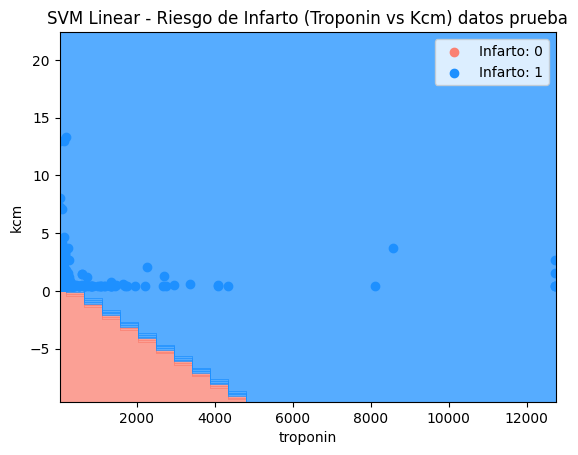

In [37]:
X_set, y_set = scaler.inverse_transform(X_test), y_test
idx_x, idx_y = 6, 7 

X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, idx_x].min() - 5, stop = X_set[:, idx_x].max() + 5, step = 1),
    np.arange(start = X_set[:, idx_y].min() - 10, stop = X_set[:, idx_y].max() + 10, step = 1)
)

X_mesh_full = np.tile(np.mean(X_train, axis=0), (X1.ravel().shape[0], 1))

temp_grid = np.zeros((X1.ravel().shape[0], 8))
temp_grid[:, idx_x] = X1.ravel()
temp_grid[:, idx_y] = X2.ravel()
scaled_points = scaler.transform(temp_grid)


X_mesh_full[:, idx_x] = scaled_points[:, idx_x]
X_mesh_full[:, idx_y] = scaled_points[:, idx_y]

# Predicción y visualización
Z = classifier.predict(X_mesh_full).reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha = 0.75, cmap = ListedColormap(('salmon', 'dodgerblue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Dibujar los puntos reales
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, idx_x], X_set[y_set == j, idx_y],
                c = ListedColormap(('salmon', 'dodgerblue'))(i), label = f'Infarto: {j}')

plt.title('SVM Linear - Riesgo de Infarto (Troponin vs Kcm) datos prueba')
plt.xlabel('troponin')
plt.ylabel('kcm')
plt.legend()
plt.show()

* Con este modelo, poder ver que su precisión asciende al 82% por lo que también esta por debajo de modelos con predicciones más elevadas como son los arboles de decisión.

## **Heart Attack con Redes Neuronales**

In [38]:
import keras
from keras.models import Sequential  
from keras import layers
from keras.layers import Dense  
import numpy  

import warnings
warnings.filterwarnings("ignore")

### Creamos modelo de Red Neuronal

In [39]:
model = keras.Sequential([
    keras.layers.Input(shape=(8,)),
    keras.layers.Dense(16, activation='relu'), #Capa entrada
    keras.layers.Dense(8, activation='relu'), #capa oculta
    keras.layers.Dense(1, activation='sigmoid')  #capa salida   
])

### Compilación y entreno del modelo

In [40]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [41]:
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1)

Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5662 - loss: 4.1355   
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6107 - loss: 1.8871  
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6218 - loss: 1.3854  
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6218 - loss: 1.0552  
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6491 - loss: 0.8435
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6431 - loss: 0.7567
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6542 - loss: 0.6654
Epoch 8/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6714 - loss: 0.6428
Epoch 9/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6714 - loss: 0.6031  
Epoch 10/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6906 - loss: 0.5746
Epoch 11/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.7118 - loss: 0.5360
Epoch 12/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

### Evaluar el modelo

In [42]:
loss, accuracy_RN = model.evaluate(X_test, y_test)
print(f"Precisión en el test: {accuracy_RN:.2f}% y perdida: {loss:.2f}%")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7848 - loss: 0.4428 
Precisión en el test: 0.78% y perdida: 0.44%


* En este ejemplo de red neuronal, la precisión ha sido del 78% por lo que también esta muy por debajo de la precisión obtenida con los arboles de decisión.

## **Resumen de precisión con cada uno de los modelos**

In [46]:
print('-' * 50)
print('Datos de Precisión de cada modelo analizado:')
print(f"Modelo Suport Vector Machine:   Accuracy: {accuracy_svm*100:.2f}%")
print(f"Modelo Red Neuronal:            Accuracy: {accuracy_RN*100:.2f}%")
print(f'Modelo K-NN:                    Accuracy: {accuracy_KNN*100:.2f}%')
print(f"Modelo Random Forest:           Accuracy: {accuracy_Random_Forest*100:.2f}%")
print(f"Modelo DecisionTreeClassifier:  Accuracy: {accuary_DTC*100:.2f}%")
print(f'Modelo Regresión:               Accuracy: {accuary_Regression*100:.2f}%')
print('-' * 50)


--------------------------------------------------
Datos de Precisión de cada modelo analizado:
Modelo Suport Vector Machine:   Accuracy: 81.82%
Modelo Red Neuronal:            Accuracy: 78.48%
Modelo K-NN:                    Accuracy: 60.30%
Modelo Random Forest:           Accuracy: 97.27%
Modelo DecisionTreeClassifier:  Accuracy: 97.88%
Modelo Regresión:               Accuracy: 76.67%
--------------------------------------------------


## **CONCLUSIONES**
* Una vez entrenado el modelo y realizadas las predicciones sobre el conjunto de los datos, mediante una regresión logística, como de un árbol de decisión, un random forest,un modelo K-NN, una red neuronal y un suport vector machine, podemos observar:

    - Para este tipo de estudios, es más preciso utilizar los árboles de decisión, tanto el **DecisionTreeClassifier** como el **RandomForestClassifier** arrojan una precisión de casi un 98%, mientras que por su parte otros modelos como el regresor logístico y la red neuronal su precisión no llega al 80%, el SVM se queda en 82% escaso y el modelo K-NN en un 60%.
    - Las variables que mayor peso tienen a la hora de presentar infarto en la predicción son la: troponina y kcm en comparación con el resto de las variables, por lo que se puede afirmar que el valor que presenten estos dos valores es un factor fundamental a la hora de poder presentar un infarto. El resto de las variables, aunque también pueden influir como puede ser el caso de la edad, su peso no es tan relevante por lo que la relación no es tan directa y no depende en gran medida para este caso.
    - Cuantos menores sean estos valores la probabilidad de haber presentado un infarto será negativa. Por el contrario, cuanto mayor sean los valores dicha probabilidad sera positiva.


* En este punto se podría ir haciendo un estudio más preciso, comparando con otras variables como la glucosa, la edad... para intentar ver o identificar algún patrón que pudiera repetirse y sacar nuevas conclusiones.

## **Detalle de las variables Troponina y KCM en la presencia de un infarto**

- **Troponina**: Es una proteína que ayuda a que el músculo del corazón se contraiga, normalmente vive dentro de las células del corazón.Es la más específica, si aparece en la sangre, es casi seguro que el daño es cardíaco.
- **CK-MB (Creatina Quinasa fracción MB)-kcm**: Es una enzima que ayuda a producir energía en los músculos, se encuentra principalmente en el corazón, pero también en pequeñas cantidades en otros músculos. Ayuda a saber cuándo ocurrió el daño, porque sube y baja más rápido que la troponina que tarda más en aumentar los valores cuando se hace un analisis de sangre.

💔 **¿Cómo se relacionan con un infarto?**
Imagina que las células del corazón son como "bolsas" llenas de estas proteínas.
+ El Bloqueo: En un infarto, una arteria se tapa y deja de llegar oxígeno al corazón.
+ La Ruptura: Sin oxígeno, las células mueren y su membrana se rompe.
+ La Fuga: Al romperse la célula, la Troponina y la CK-MB se escapan hacia el torrente sanguíneo.
+ La Detección: El médico saca sangre, mide estas sustancias y, si los niveles son altos, confirma que hubo muerte de tejido cardíaco. 

⏱️ **Diferencias clave en el tiempo**

| Biomarcador | ¿Cuándo aparece?    |¿Cuánto dura elevado? |
|:-----------:|:-------------------:|:--------------------:|
| Troponina	  | 3 a 6 horas después	|  Hasta 10 o 14 días  |
| CK-MB	      | 4 a 6 horas después	|  Solo 2 a 3 días     |

**¿Por qué importa esto?**

+ Si un paciente tiene un segundo infarto a los pocos días del primero, la CK-MB es mejor para detectarlo porque la troponina del primer infarto todavía sigue alta en la sangre. 

💡 **En resumen**

+ **Troponina**: Dice "Sí, el corazón sufrió daño". Es muy precisa.
+ **CK-MB**: Dice "El daño es reciente". Ayuda a ver la evolución.

La presencia de estos valores altos indica que el daño ya ocurrió o está ocurriendo en ese preciso momento.
- Nota: a veces la troponina sube por ejercicio intenso y no es un infarto
- Otros biomarcadores como la Mioglobina son interesantes de analizar.
- Factores como el colesterol o la presión arterial, sí sirven para ver la probabilidad  de sufrir un infarto a futuro.